In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.patches as patches

In [2]:
def read_nfixedpoints_file(filepath):
    data = np.loadtxt(filepath, comments='#')
    return data

In [3]:
def plot_nfixedpoints_gnuplot(data, val_filter, param_list_to_plot, pos_filter=0, 
                              pos_param=1, pos_xplot=2, plot_title=None,
                              xmin=None, xmax=None, ymin=None, ymax=None,
                              figsize=(8, 6), dpi=150, legend_loc='best', ncols_legend=1,
                              xlabel=None, ylabel=None, title_fontsize=18, label_fontsize=20,
                              tick_fontsize=14, legend_fontsize=14, save_to=None,
                              markersize=8, linewidth=2, markers=None, tol=1e-9,
                              color_offset=0, legend_title=None, 
                              label_param="N", type_param=int, logscalex=True, 
                              logscaley=False):
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "stix",
        "axes.linewidth": 1.2,
    })
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    if markers is None:
        markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', 'h', '<', '>']

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    fig.subplots_adjust(left=0.15, bottom=0.14, right=0.98, top=0.92)

    mask_filter = np.isclose(data[:, pos_filter], val_filter, atol=tol)
    data_filtered = data[mask_filter]

    for idx, param in enumerate(param_list_to_plot):
        color = color_cycle[(idx + color_offset) % len(color_cycle)]
        marker = markers[idx % len(markers)]

        mask_param = data_filtered[:, pos_param] == param
        sub = data_filtered[mask_param]
        if len(sub) == 0:
            continue
        sub = sub[np.argsort(sub[:, pos_xplot])]
        xdata = sub[:, pos_xplot]
        nfixedpoints_norm = (sub[:, 3]) / sub[:, 2]

        ax.plot(xdata, nfixedpoints_norm, marker=marker, linestyle='-', linewidth=linewidth,
                markersize=markersize, label=rf'{label_param}={type_param(param)}', 
                color=color)
    if logscalex:
        ax.set_xscale('log')
    if logscaley:
        ax.set_yscale('log')
    ax.set_xlabel(xlabel if xlabel is not None else r"$n_{\rm init}$", fontsize=label_fontsize)
    ax.set_ylabel(ylabel if ylabel is not None else r"$n_{\rm fixed}/n_{\rm init}$", fontsize=label_fontsize)
    ax.set_title(plot_title if plot_title is not None else rf"$\mu={val_filter}$", fontsize=title_fontsize)

    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=3)
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                   labelsize=tick_fontsize, length=5)
    if logscalex:
        ax.xaxis.set_major_formatter(LogFormatterMathtext())
    if logscaley:
        ax.yaxis.set_major_formatter(LogFormatterMathtext())

    if xmin is not None:
        ax.set_xlim(left=xmin)
    if xmax is not None:
        ax.set_xlim(right=xmax)
    if ymin is not None:
        ax.set_ylim(bottom=ymin)
    if ymax is not None:
        ax.set_ylim(top=ymax)
    ax.legend(loc=legend_loc, fontsize=legend_fontsize, frameon=False, handlelength=2.5,
              ncol=ncols_legend, title=legend_title)

    if save_to is not None:
        plt.savefig(save_to)
    plt.show()

In [4]:
path_nfixedpoints = ("/run/media/david/Data/Research/Ecology/Results/IBMF/Counting_fixed_points/"
                      "IBMF_T0_seq_gr_inside_RRG_eps_0.000_sigma_0.000_c_3_seedgraph_3_Lotka_Volterra_final_"
                      "av0_0.500_dn_0.500_tol_1.0e-06_maxiter_10000_damping_1.00_nfixedpoints.txt")

data_nfixedpoints = read_nfixedpoints_file(path_nfixedpoints)

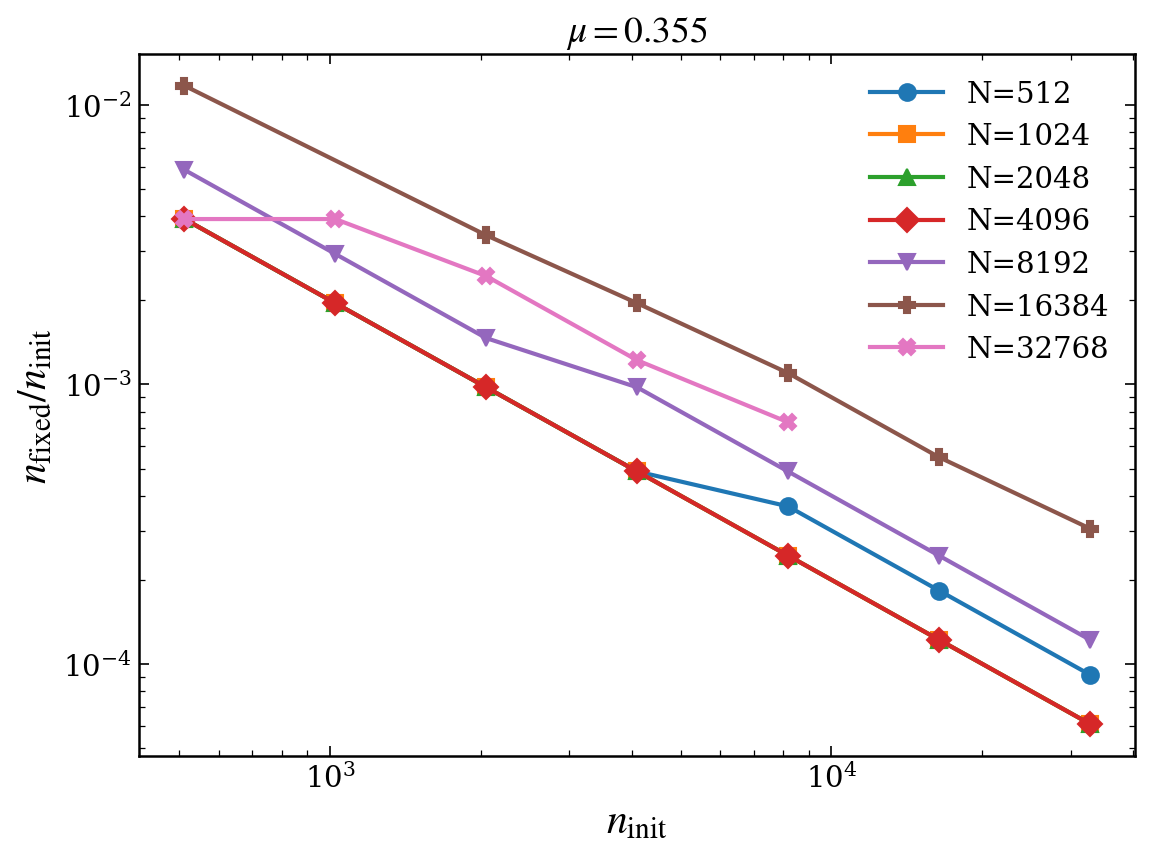

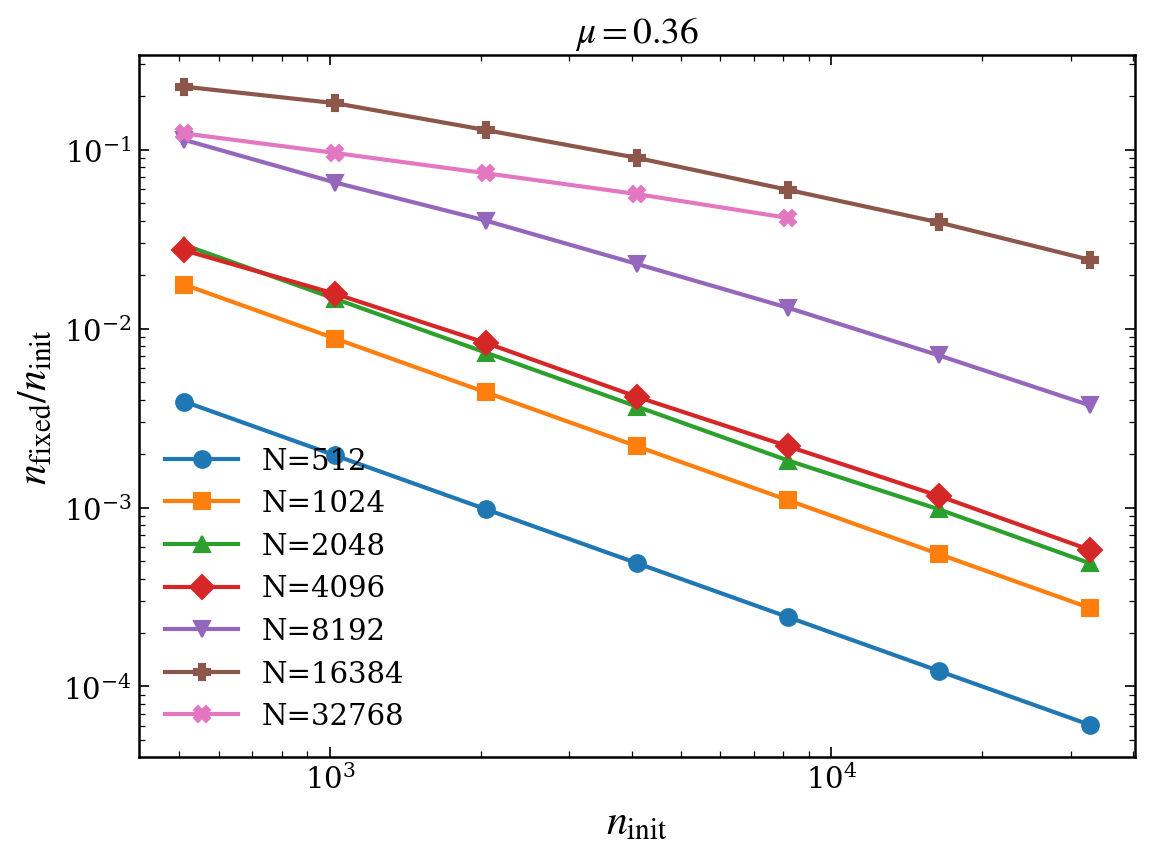

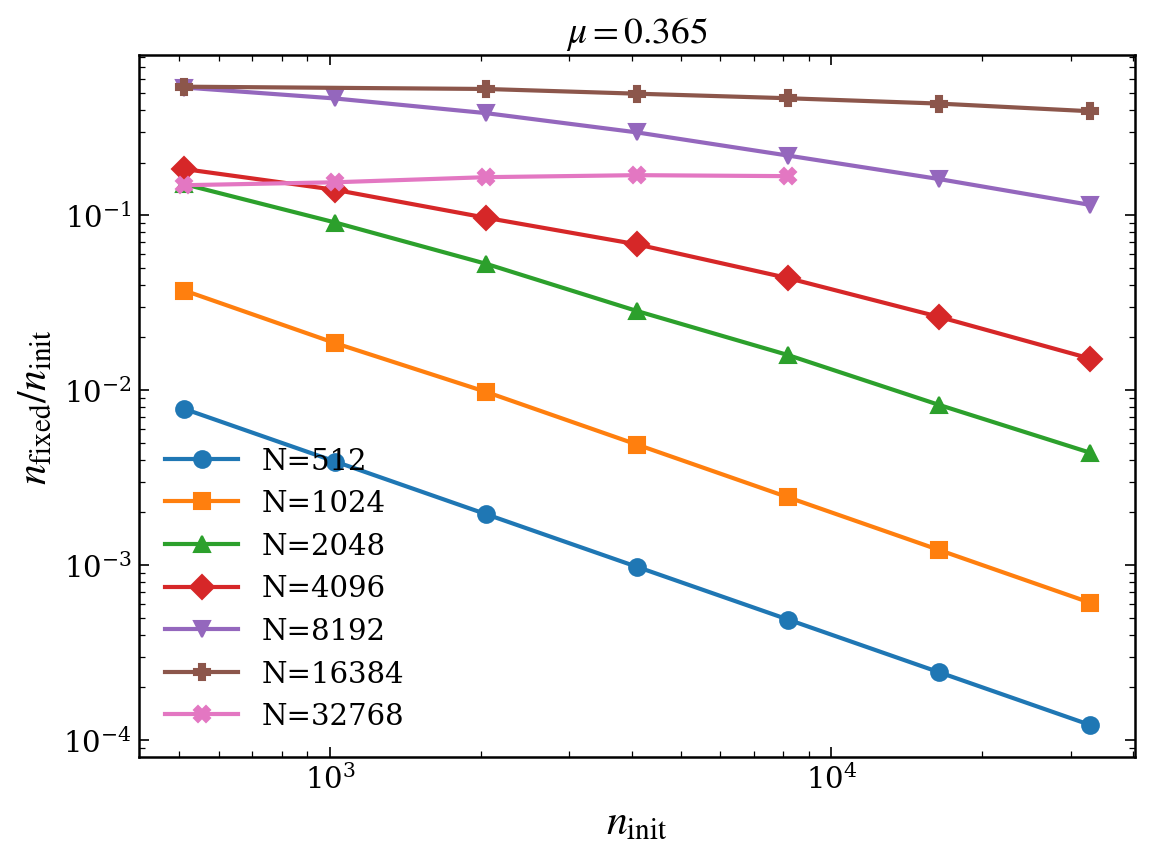

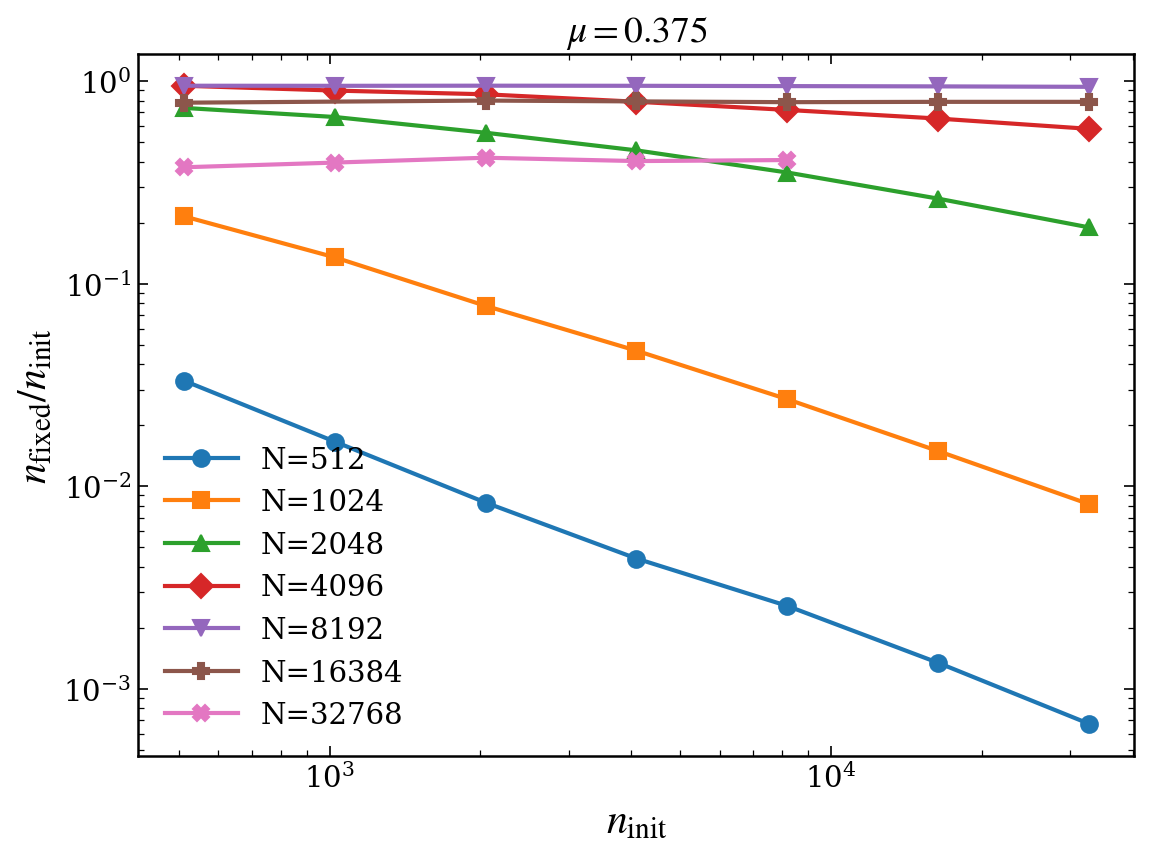

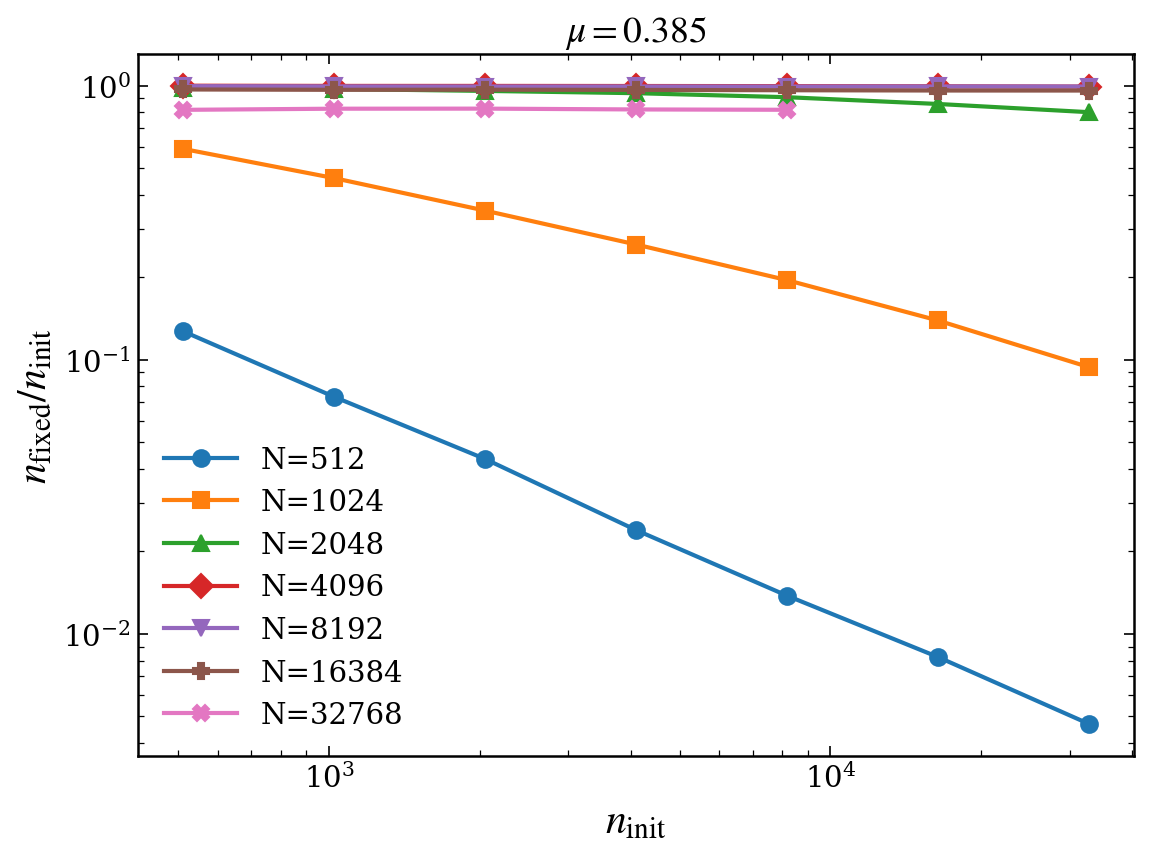

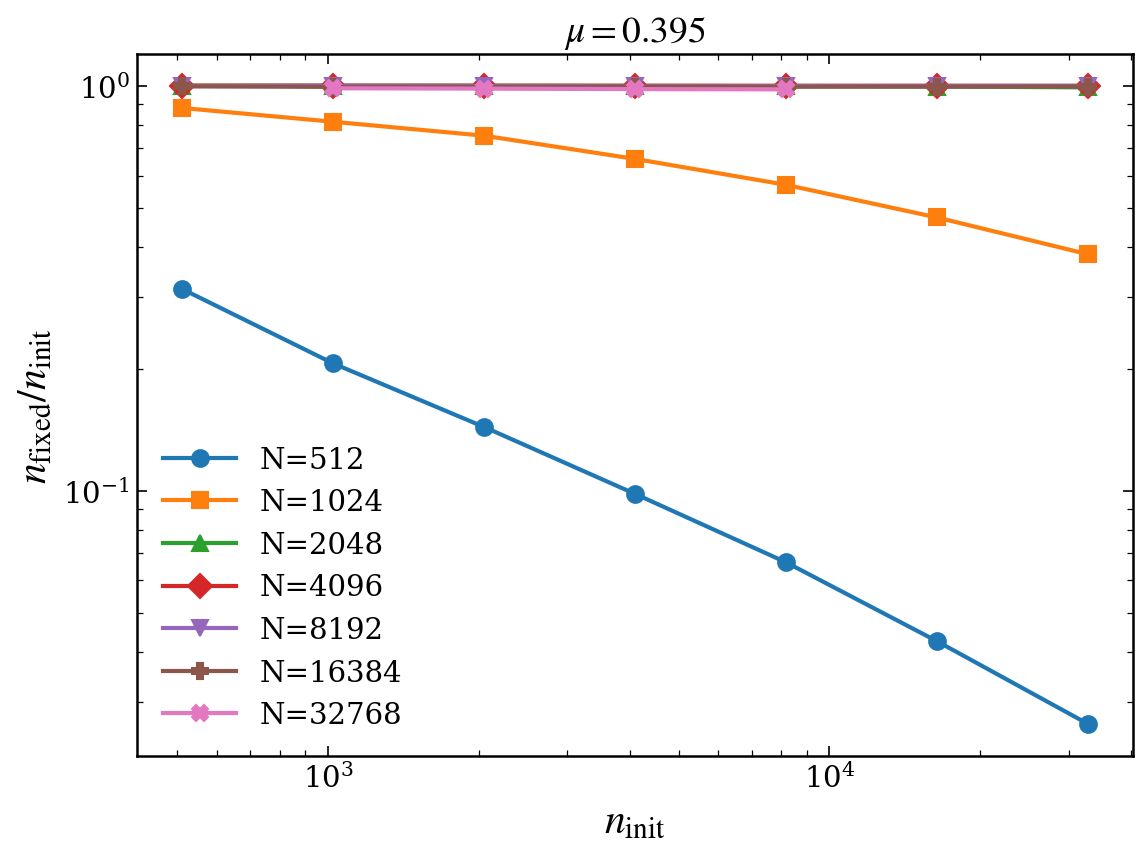

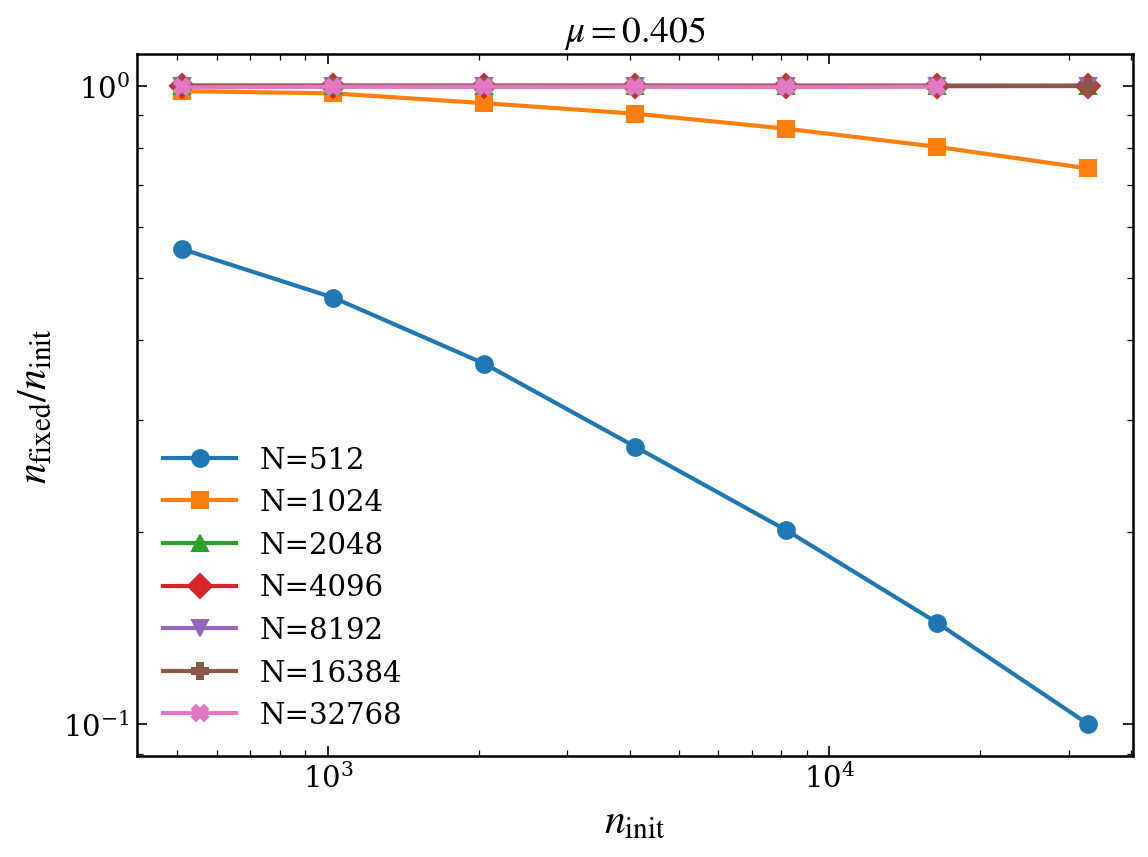

In [6]:
# mu_values = np.unique(data_nfixedpoints[:, 0])
mu_values = [0.355, 0.360, 0.365, 0.375, 0.385, 0.395, 0.405]
N_values = [512, 1024, 2048, 4096, 8192, 16384, 32768]

for mu in mu_values:
    plot_nfixedpoints_gnuplot(data_nfixedpoints, mu, N_values, logscaley=True)

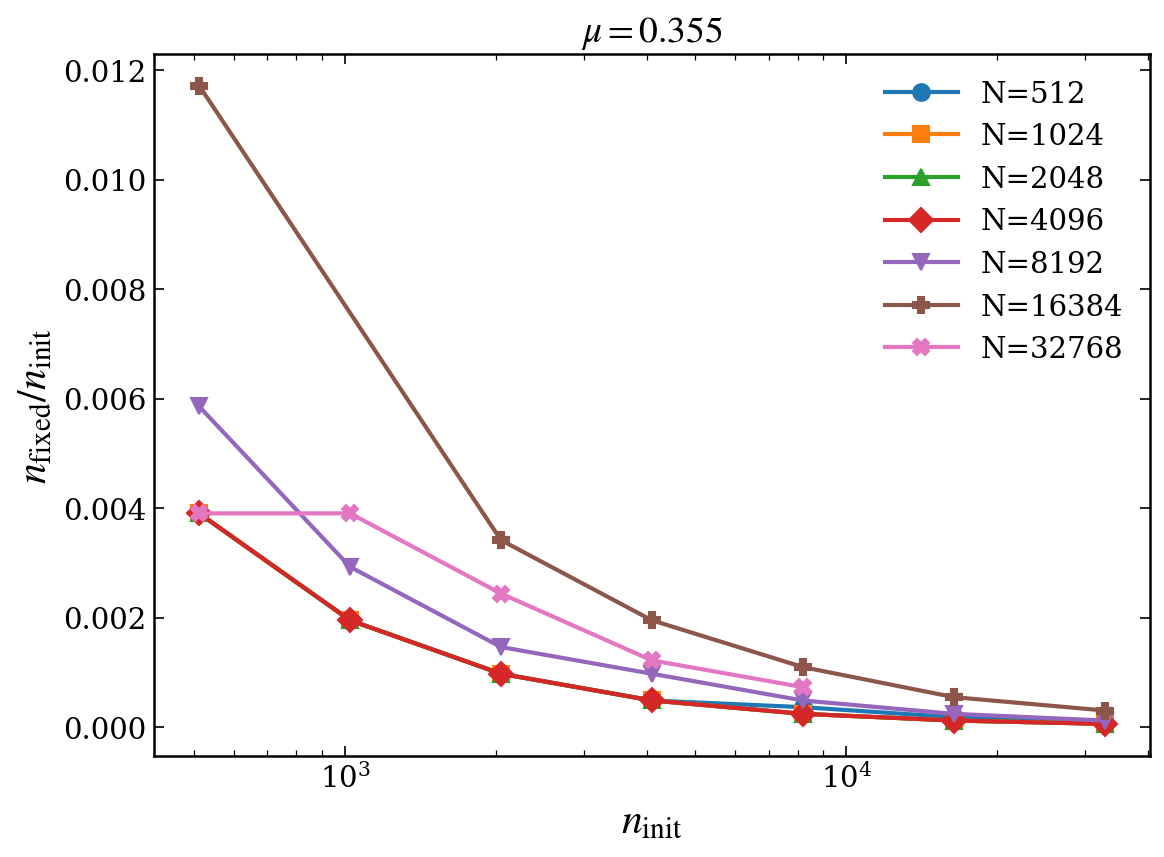

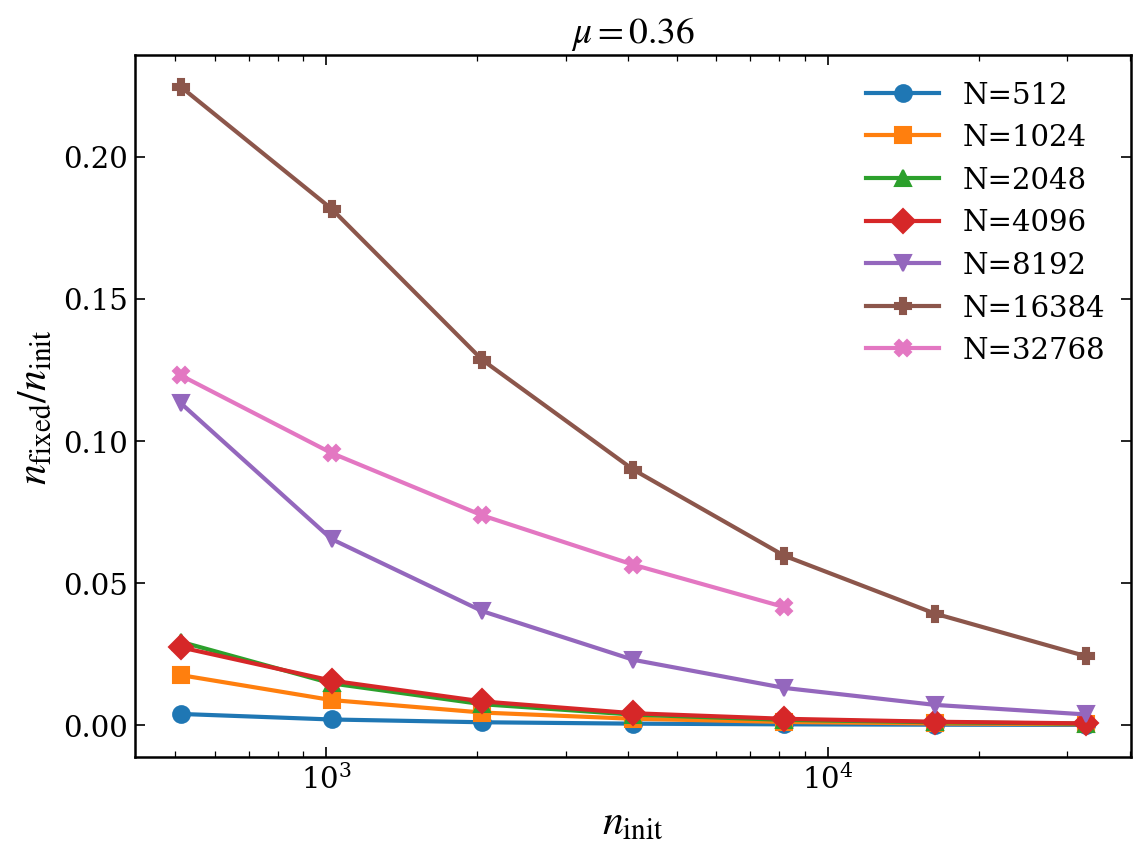

In [18]:
mu_values = [0.355, 0.360]
N_values = [512, 1024, 2048, 4096, 8192, 16384, 32768]

for mu in mu_values:
    plot_nfixedpoints_gnuplot(data_nfixedpoints, mu, N_values)

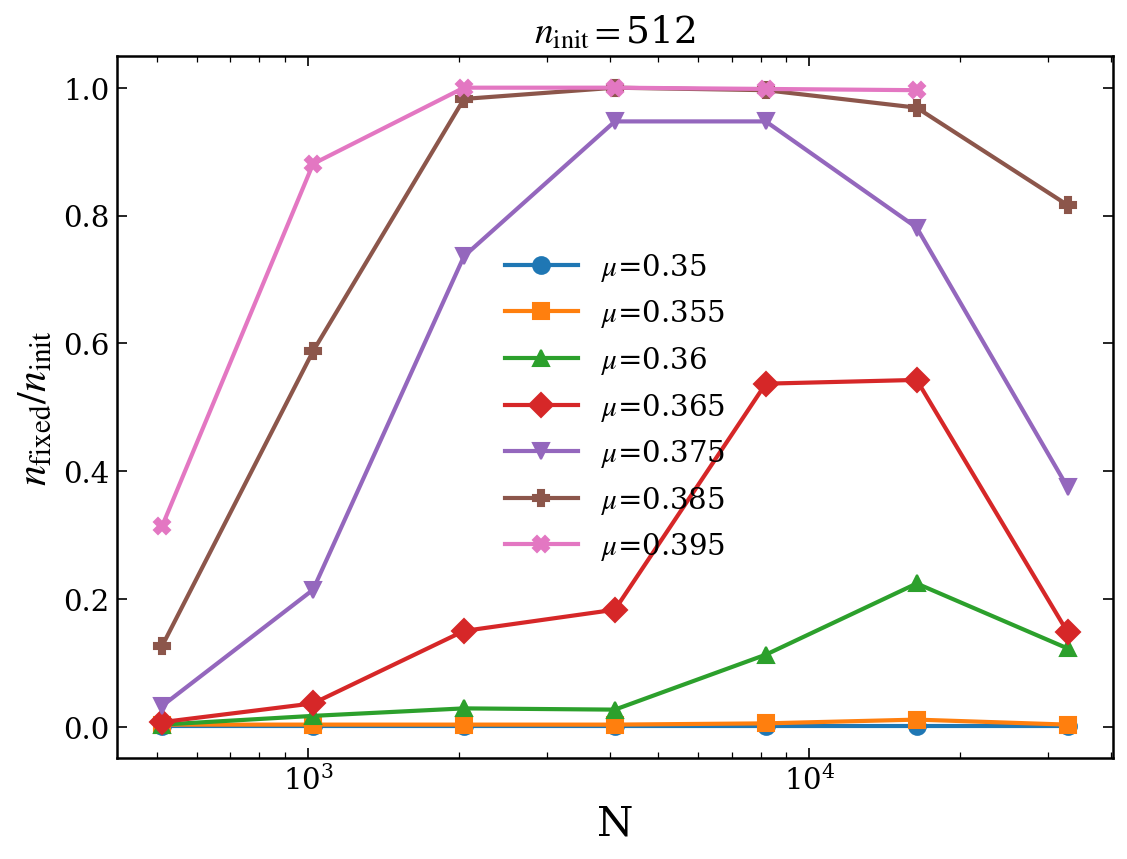

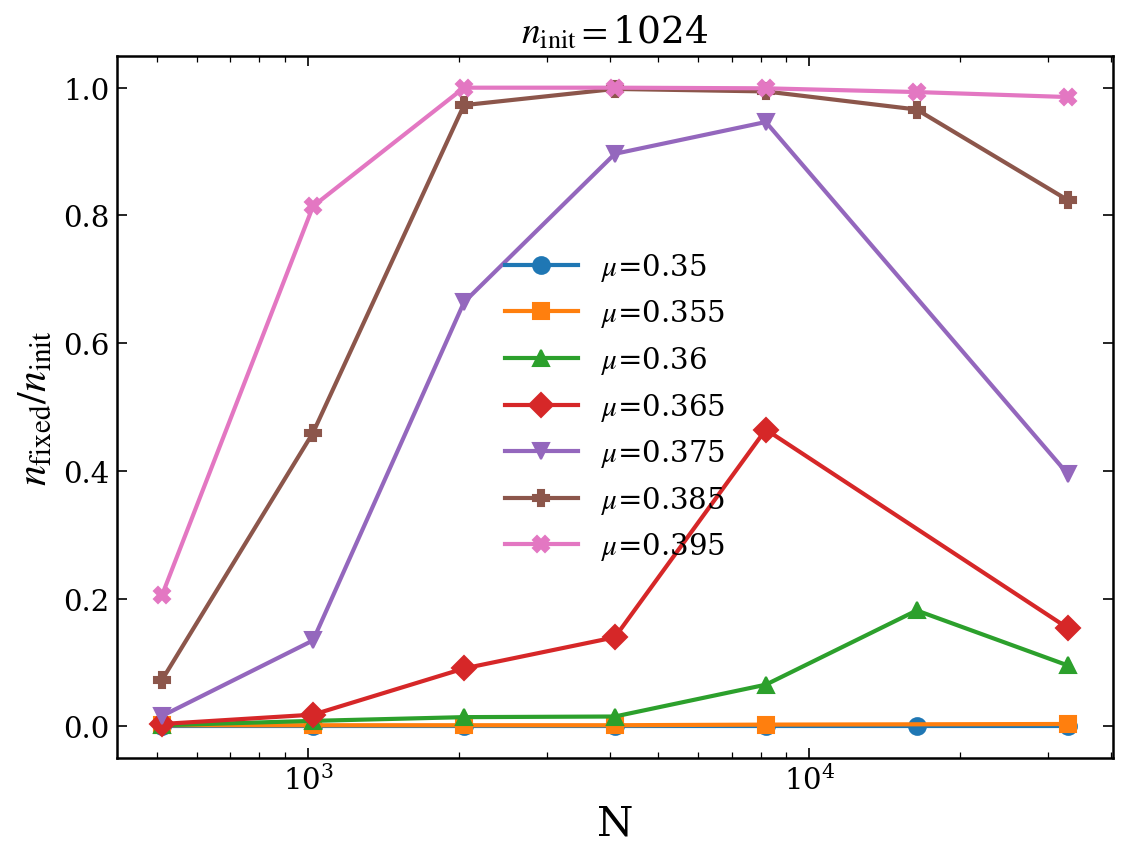

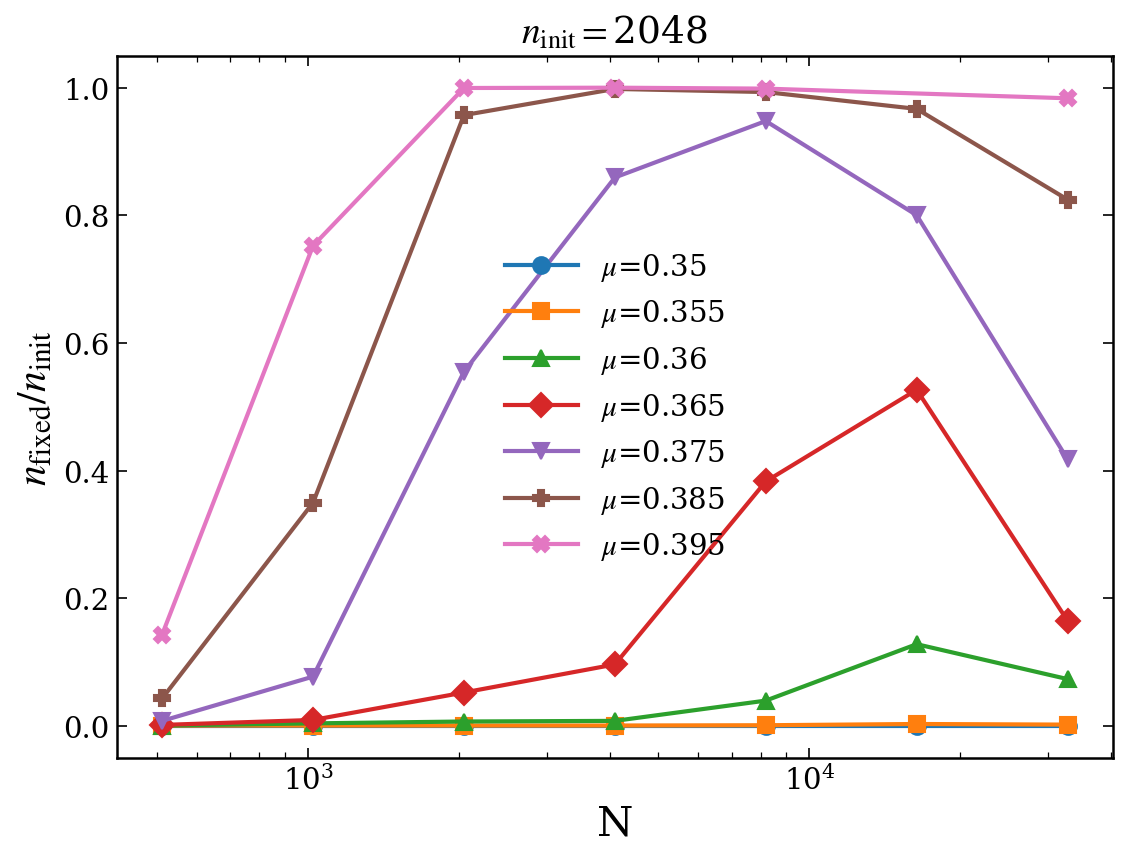

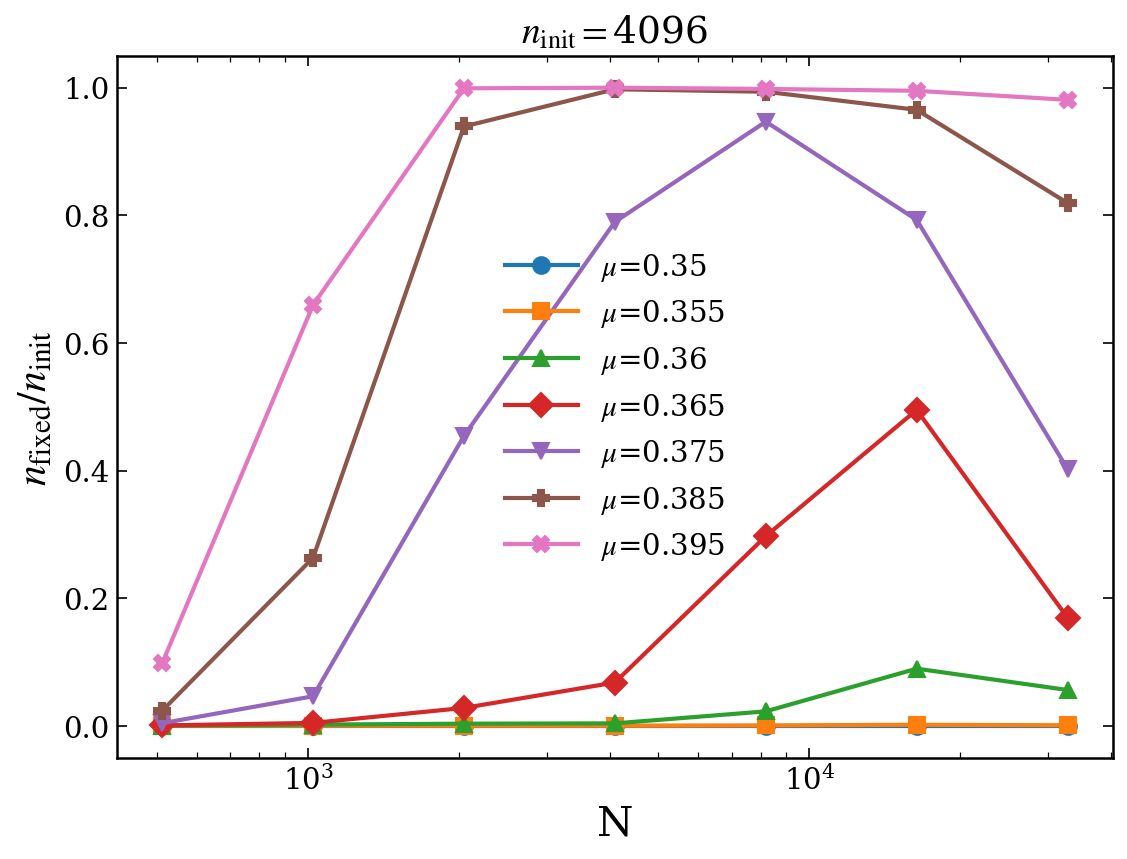

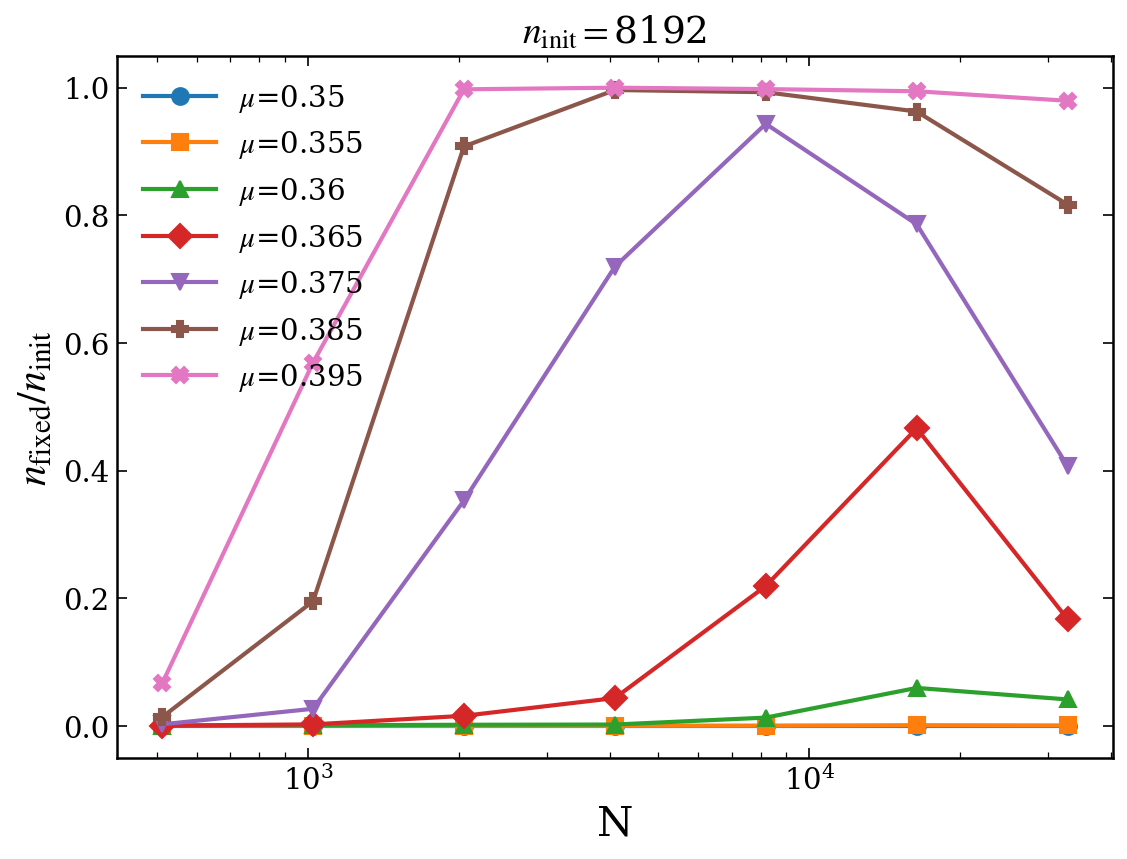

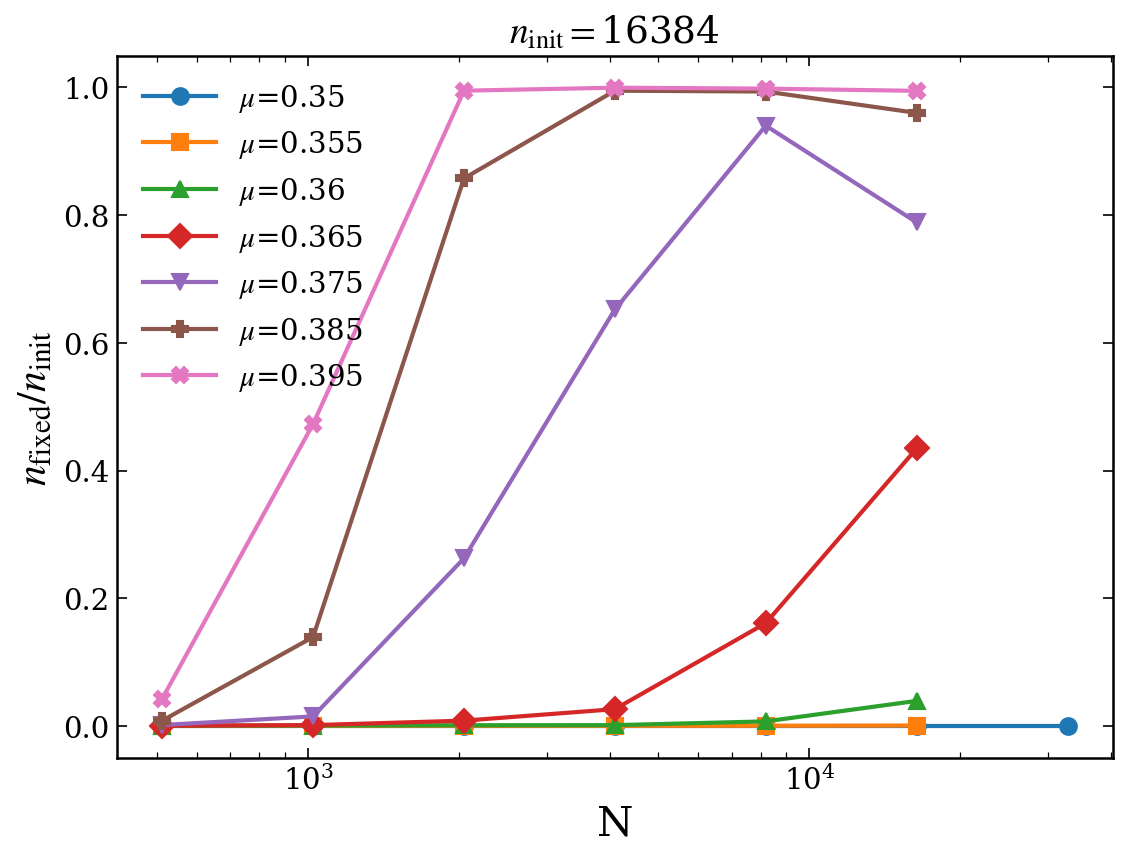

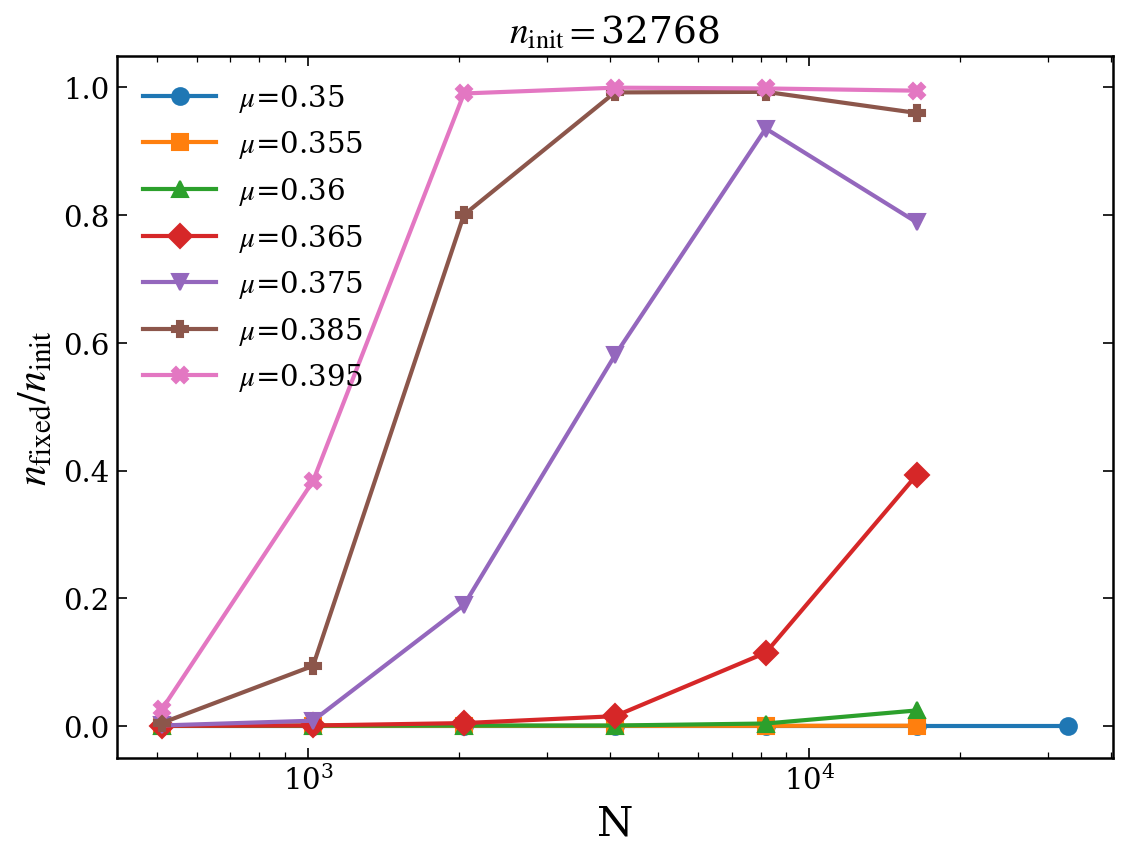

In [19]:
mu_values = [0.350, 0.355, 0.360, 0.365, 0.375, 0.385, 0.395]
ninitcond_values = np.unique(data_nfixedpoints[:, 2])

for ninitcond in ninitcond_values:
    plot_nfixedpoints_gnuplot(data_nfixedpoints, ninitcond, mu_values, pos_filter=2, pos_param=0, 
                              pos_xplot=1, label_param=r"$\mu$", type_param=float, 
                              plot_title=r"$n_{\rm init}=$" + str(int(ninitcond)), 
                              xlabel="N")

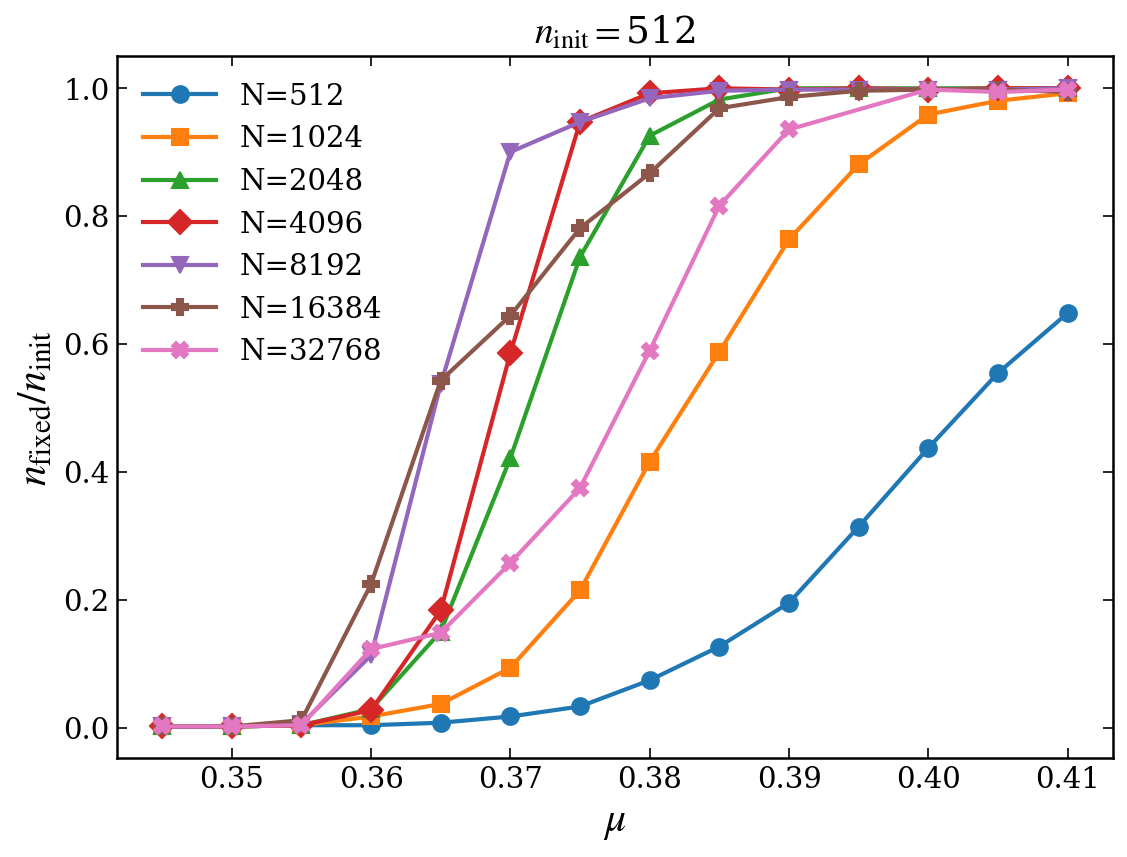

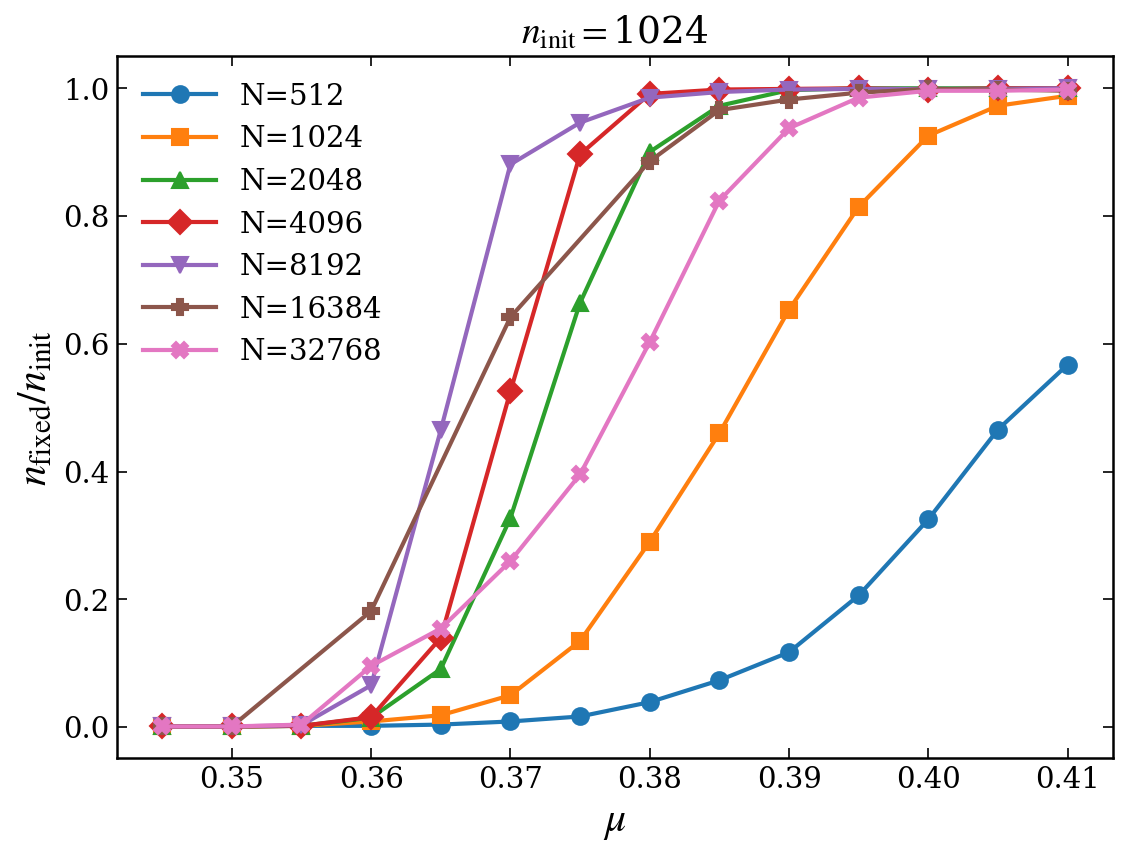

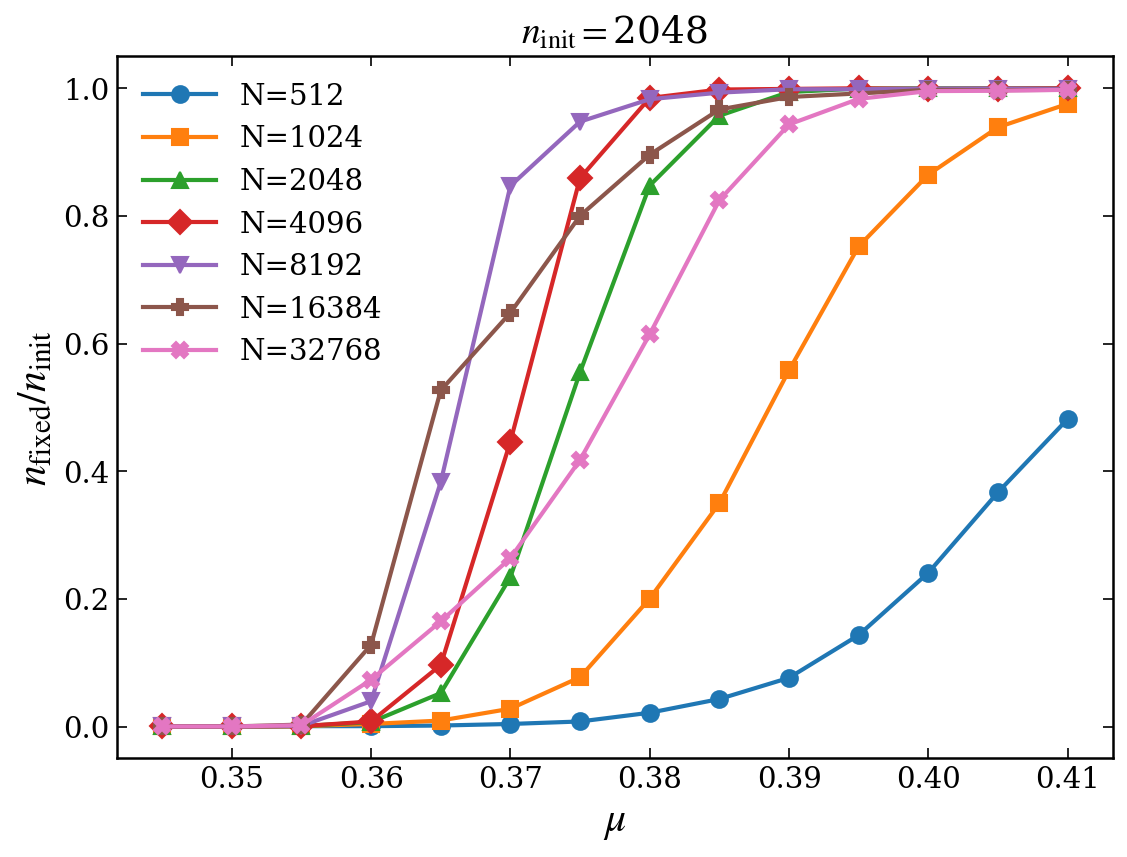

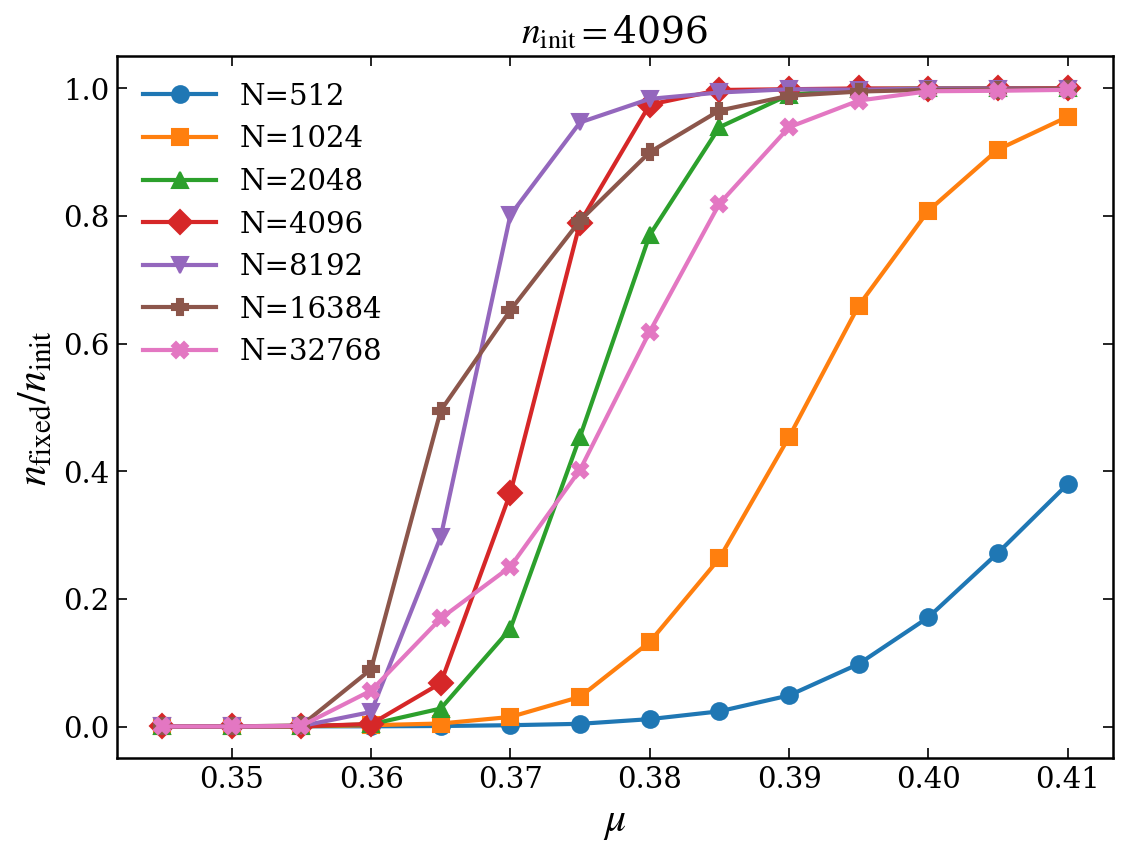

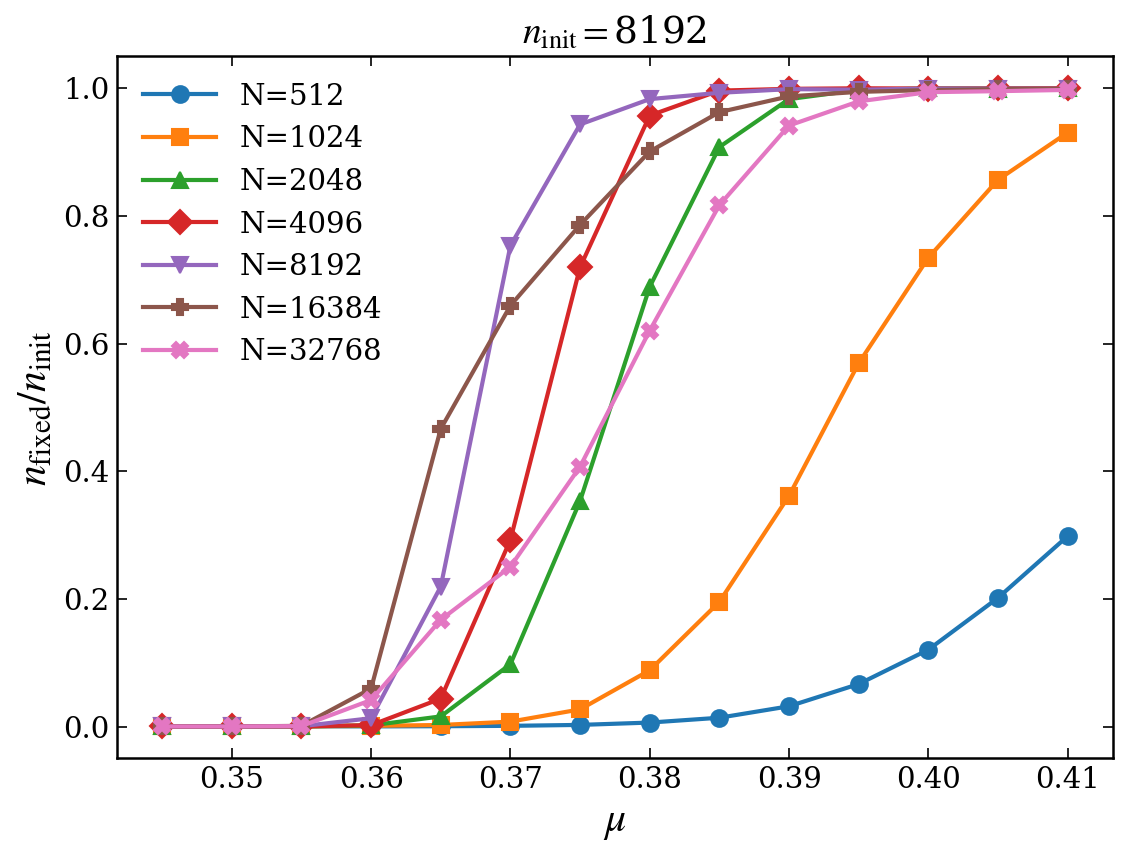

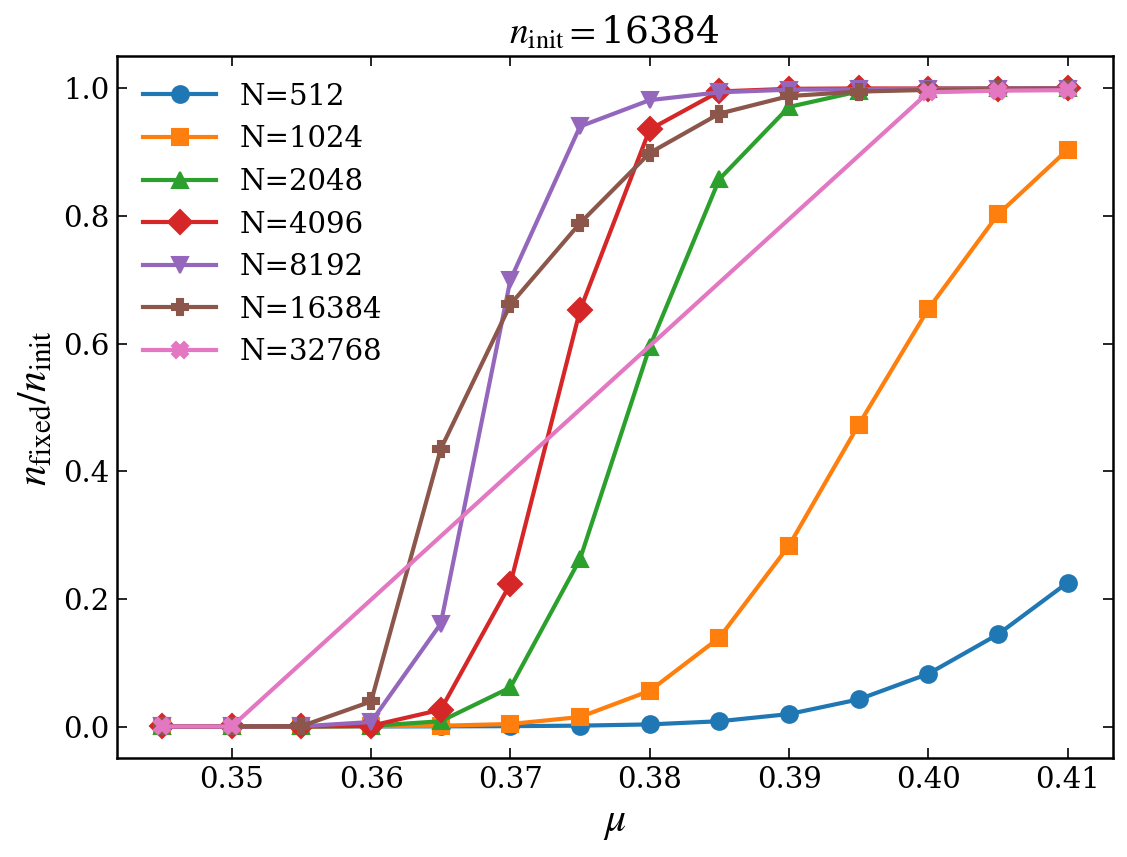

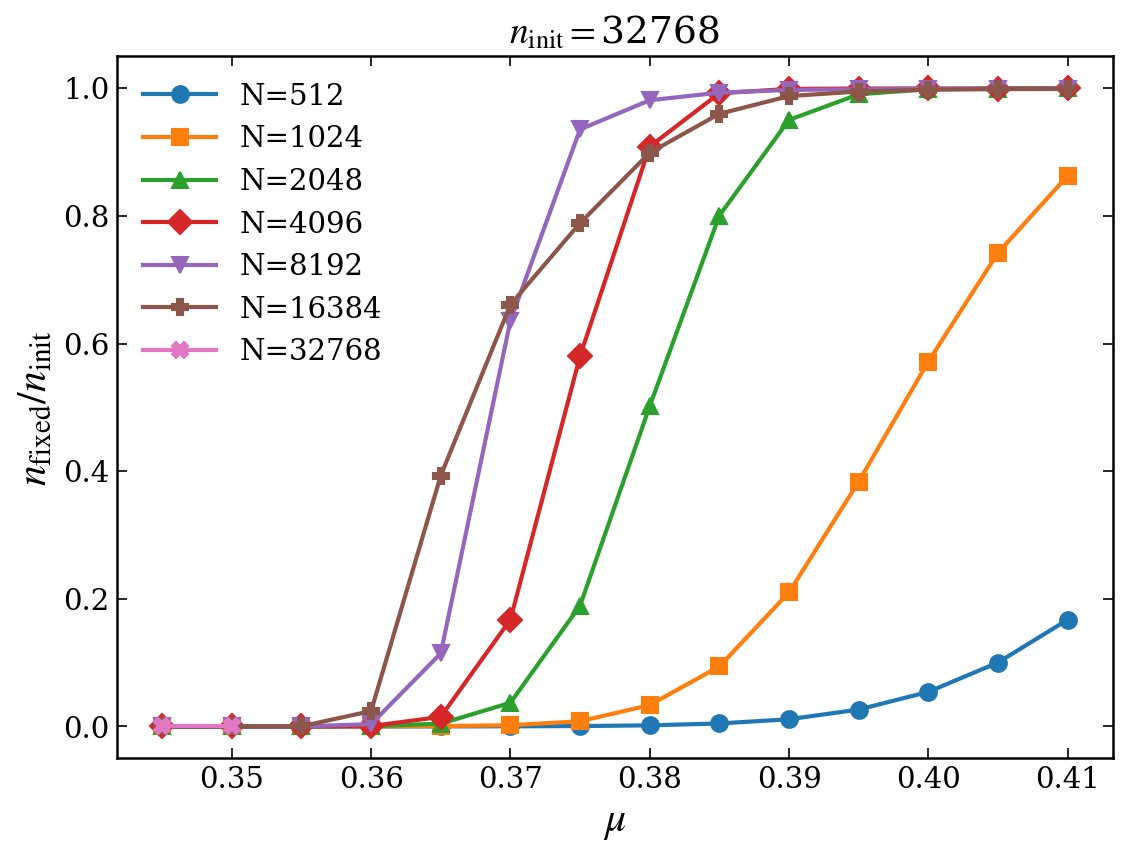

In [20]:
N_values = [512, 1024, 2048, 4096, 8192, 16384, 32768]
ninitcond_values = np.unique(data_nfixedpoints[:, 2])

for ninitcond in ninitcond_values:
    plot_nfixedpoints_gnuplot(data_nfixedpoints, ninitcond, N_values, pos_filter=2, 
                              pos_param=1, pos_xplot=0, label_param="N", type_param=int,
                              plot_title=r"$n_{\rm init}=$" + str(int(ninitcond)),
                              xlabel=r"$\mu$", logscalex=False)